# LambdaLLG 2D Quickstart

This notebook runs a minimal 2D simulation and computes both the
time-series of average magnetization and a final-state `m_z` map.


In [1]:
using LambdaLLG
using Random
using Statistics
using LinearAlgebra

Random.seed!(2)

TaskLocalRNG()

## 1. Define model parameters


In [3]:
Nx, Ny = 20, 20
J = 1.0
K = (0.0, 0.0, -0.02)
B = (0.0, 0.0, -0.10)
αG = 0.05

p = LLGParams2D(Nx, Ny, J, K, B, αG);

## 2. Build a normalized initial spin texture


In [4]:
s0 = zeros(3, Nx, Ny)
for j in 1:Ny, i in 1:Nx
    θ = 0.15 + 0.02 * randn()
    ϕ = 2pi * rand()
    v = [sin(θ) * cos(ϕ), sin(θ) * sin(ϕ), cos(θ)]
    s0[:, i, j] .= v 
end

## 3. Integrate the dynamics


In [5]:
tspan = (0.0, 20.0)
sol = evolve2D(s0, tspan, p)

(length(sol.t), sol.t[1], sol.t[end])

(403, 0.0, 20.0)

## 4. Post-process observables


In [6]:
mz = [mean(reshape(u, 3, Nx, Ny)[3, :, :]) for u in sol.u]
final_mz = reshape(sol.u[end], 3, Nx, Ny)[3, :, :]

(length(mz), size(final_mz))

(403, (20, 20))

## 5. Optional plots

This cell draws a time-series and a final-state heatmap if `PyPlot` is installed.

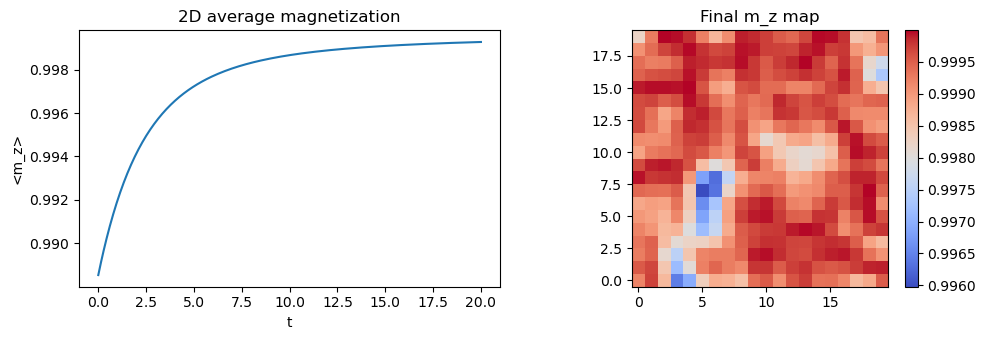

In [7]:
import PyPlot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[1].plot(sol.t, mz)
ax[1].set_xlabel("t")
ax[1].set_ylabel("<m_z>")
ax[1].set_title("2D average magnetization")

im = ax[2].imshow(final_mz, origin="lower", cmap="coolwarm")
ax[2].set_title("Final m_z map")
fig.colorbar(im, ax=ax[2], fraction=0.046, pad=0.04)
plt.tight_layout()